## 0. Environment setting

In [1]:
import os
import logging
import tensorflow as tf
from tensorflow.keras import mixed_precision

# 1. Support logs: Suppress TensorFlow logging (0 = all logs, 1 = filter INFO, 2 = filter WARNING, 3 = filter ERROR)
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3' 

# This stops the 'already registered' warnings from flooding the output
logger = tf.get_logger()
logger.setLevel(logging.ERROR)

# 2.  Enable Mixed Precision for T4 GPUs: tells the T4 GPUs to use 16-bit math where possible, As we will choose 2 T4
policy = mixed_precision.Policy('mixed_float16')
mixed_precision.set_global_policy(policy)

# 3. Strategy for 2 GPUs
strategy = tf.distribute.MirroredStrategy()
print(f"GPUs working: {strategy.num_replicas_in_sync}")

# 4. Load models
# (Check the sidebar to make sure the folder name matches exactly)
LOAD_PATH = '/kaggle/input/models/damonwangzc/densenet121-v04-8-epoches/tensorflow2/default/1/best_chest_model.keras'

with strategy.scope():
    print("Loading model from Epoch 8...")
    model = tf.keras.models.load_model(LOAD_PATH)
    print("Model loaded!")

2026-03-31 11:58:44.891368: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774958325.320506      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774958325.437728      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1774958326.430712      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774958326.430755      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774958326.430759      24 computation_placer.cc:177] computation placer alr

GPUs working: 2
Loading model from Epoch 8...
Model loaded!


## 1. Exploratory Data Analysis
### 1.1 Load Data and Mape Image Path

In [2]:
import numpy as np
import pandas as pd
import os
from glob import glob
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the main CSV
dataset_path = "/kaggle/input/datasets/organizations/nih-chest-xrays/data"  # copy from "NIH Chest X-rays" in the left side
df = pd.read_csv(dataset_path + '/Data_Entry_2017.csv')

# 2. Map image paths
# This creates a dictionary where Key = '00000001_000.png' and Value = 'full/path/to/00000001_000.png'
all_image_paths = {os.path.basename(x): x for x in 
                   glob(os.path.join(dataset_path, 'images_*', 'images', '*.png'))}

print(f"Total images found: {len(all_image_paths)}")

# 3. Add the full path to the dataframe
df['path'] = df['Image Index'].map(all_image_paths.get)

# Quick check
df.head()

Total images found: 112120


,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Gender,View Position,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,y],Unnamed: 11,path
0,00000001_000.png,Cardiomegaly,0,1,58,M,PA,2682,2749,0.143,0.143,NaN,/kaggle/input/datasets/organizations/nih-chest...
1,00000001_001.png,Cardiomegaly|Emphysema,1,1,58,M,PA,2894,2729,0.143,0.143,NaN,/kaggle/input/datasets/organizations/nih-chest...
2,00000001_002.png,Cardiomegaly|Effusion,2,1,58,M,PA,2500,2048,0.168,0.168,NaN,/kaggle/input/datasets/organizations/nih-chest...
3,00000002_000.png,No Finding,0,2,81,M,PA,2500,2048,0.171,0.171,NaN,/kaggle/input/datasets/organizations/nih-chest...
4,00000003_000.png,Hernia,0,3,81,F,PA,2582,2991,0.143,0.143,NaN,/kaggle/input/datasets/organizations/nih-chest...


### 1.2 Clearn and Process Labels

In [3]:
# Define the 14 pathology labels (excluding 'No Finding')
pathologies = ['Atelectasis', 'Consolidation', 'Infiltration', 'Pneumothorax', 'Edema', 
               'Emphysema', 'Fibrosis', 'Effusion', 'Pneumonia', 'Pleural_Thickening', 
               'Cardiomegaly', 'Nodule', 'Mass', 'Hernia']

# Create a column for each pathology (1 if present, 0 if not)
for pathology in pathologies:
    df[pathology] = df['Finding Labels'].apply(lambda x: 1 if pathology in x else 0)

# Check the distribution of 'No Finding' vs Diseases
df['No Finding'] = df['Finding Labels'].apply(lambda x: 1 if 'No Finding' in x else 0)

print(f"Number of 'No Finding' cases: {df['No Finding'].sum()}")

Number of 'No Finding' cases: 60361


### 1.3 Visualize Class Imbalance

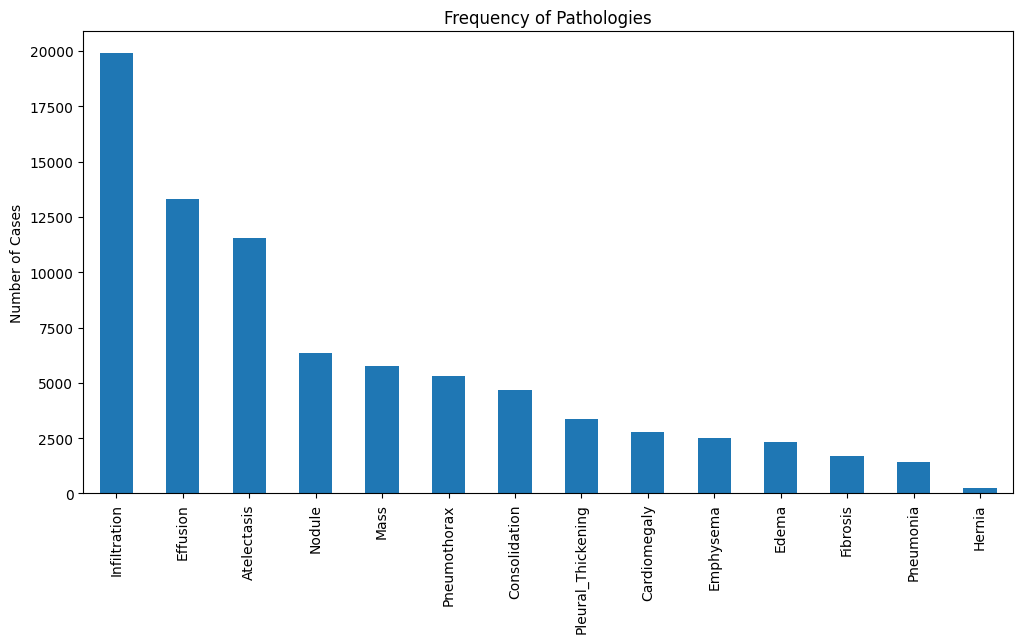

In [4]:
plt.figure(figsize=(12, 6))
df[pathologies].sum().sort_values(ascending=False).plot(kind='bar')
plt.title('Frequency of Pathologies')
plt.ylabel('Number of Cases')
plt.show()

### 1.4 Visulize Sample Images

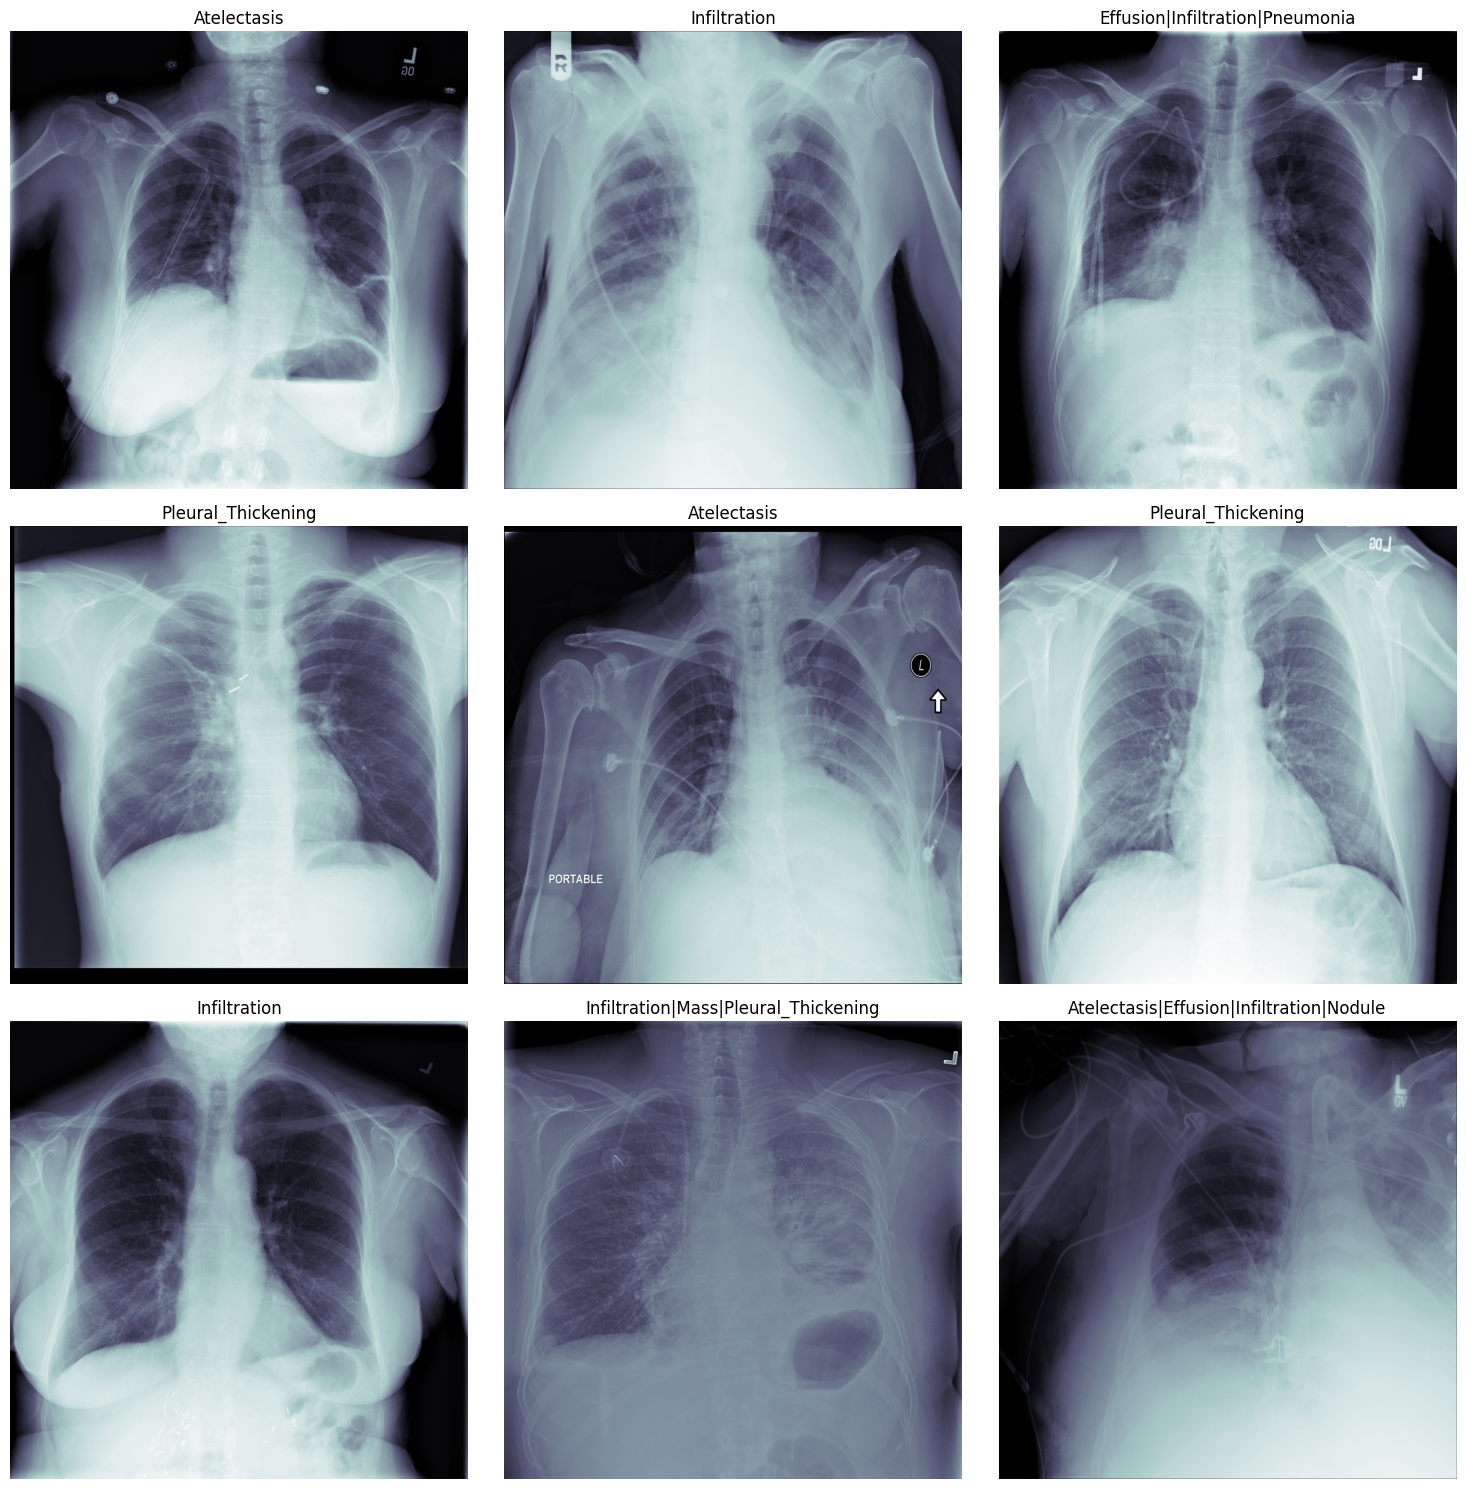

In [5]:
# Plot a few random images with their labels
sample_df = df[df['Finding Labels'] != 'No Finding'].sample(9)

plt.figure(figsize=(15, 15))
for i, (index, row) in enumerate(sample_df.iterrows()):
    plt.subplot(3, 3, i+1)
    img = plt.imread(row['path'])
    plt.imshow(img, cmap='bone')
    plt.title(row['Finding Labels'])
    plt.axis('off')
plt.tight_layout()

⚠️ ### **Critical "Pro-Tip" for this Dataset: Patient Overlap**

The most common mistake on this dataset is splitting by Image.

* One patient might have 10 X-rays taken over a month.
* If you put 8 of those in Train and 2 in Test, your model will "memorize" that specific patient's rib cage/anatomy rather than learning the disease.
* **Result**: You get a fake 95% accuracy that fails in the real world.

**Always split by Patient ID**, not by image index.

## 2. Data Preprocessing & Input Pipeline

### 2.1 Patient-Wise Split 

In [6]:
from sklearn.model_selection import train_test_split

# 1. Get all unique Patient IDs
patient_ids = df['Patient ID'].unique()

# 2. Split Patient IDs: 80% Train, 20% Temporary (which we split into Val/Test)
train_ids, test_val_ids = train_test_split(patient_ids, test_size=0.20, random_state=42)

# 3. Split the 20% into half Validation and half Test (10% each of total)
val_ids, test_ids = train_test_split(test_val_ids, test_size=0.50, random_state=42)

# 4. Create the actual DataFrames based on these IDs
train_df = df[df['Patient ID'].isin(train_ids)]
valid_df = df[df['Patient ID'].isin(val_ids)]
test_df = df[df['Patient ID'].isin(test_ids)]

print(f"Train samples: {len(train_df)} | Val samples: {len(valid_df)} | Test samples: {len(test_df)}")

# Sanity Check: Ensure no patient is in both Train and Test
assert len(set(train_df['Patient ID']).intersection(set(test_df['Patient ID']))) == 0
print("Success: No patient overlap between sets!")

Train samples: 89826 | Val samples: 10930 | Test samples: 11364
Success: No patient overlap between sets!


### 2.2 Consolidated Preprocessing & Generator

**Medical-Specific Data Augmentation**

* Horizontal Flip: Valid (the heart is usually on the left, but slight symmetry helps the model generalize).

* Rotation: Very slight (e.g., ±5 to 10 degrees) to simulate patients who were slightly tilted during the X-ray.

* Zoom/Shear: Very slight (±5%) to simulate different distances from the sensor.

* Brightness/Contrast: Slight adjustment to handle different X-ray machine exposures.

**Image Contrast Enhancement (CLAHE):**

* X-ray images often have very low contrast or are "washed out." CLAHE (Contrast Limited Adaptive Histogram Equalization) is a common medical technique to make the features (like nodules or lung textures) pop.

**Create TensorFlow Image Data Generators**
* we will use 320 x 320 to find small nodules or subtle lung textures

In [7]:
import cv2
from tensorflow.keras.preprocessing.image import ImageDataGenerator

def medical_preprocessing(img):
    """
    Combines CLAHE and Normalization in one step.
    Expects input as 0-255 uint8 (which is how Keras loads them before rescaling).
    """
    # 1. Ensure image is uint8
    img = img.astype(np.uint8)

    # 2. Create CLAHE
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))

    # 3. Handle channels (Ensuring 3-channel output for DenseNet)
    if len(img.shape) == 2: # Grayscale
        img_clahe = clahe.apply(img)
        img_final = cv2.cvtColor(img_clahe, cv2.COLOR_GRAY2RGB)
    elif img.shape[2] == 1: # Grayscale with channel dim
        img_clahe = clahe.apply(img[:,:,0])
        img_final = cv2.cvtColor(img_clahe, cv2.COLOR_GRAY2RGB)
    else: # RGB
        lab = cv2.cvtColor(img, cv2.COLOR_RGB2LAB)
        l, a, b = cv2.split(lab)
        l2 = clahe.apply(l)
        lab = cv2.merge((l2, a, b))
        img_final = cv2.cvtColor(lab, cv2.COLOR_LAB2RGB)

    # 4. Normalize to [0, 1] HERE
    return img_final.astype(np.float32) / 255.0

# Define parameters
IMG_SIZE = (320, 320)
BATCH_SIZE = 32 * strategy.num_replicas_in_sync # 64 total

# --- THE GENERATOR ---
# NO 'rescale=1./255' here because medical_preprocessing does it!
train_datagen = ImageDataGenerator(
    preprocessing_function=medical_preprocessing,
    horizontal_flip=True,
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    fill_mode='constant',
    cval=0
)

# Use the same object for Validation (but without the random augmentations)
val_datagen = ImageDataGenerator(
    preprocessing_function=medical_preprocessing
)

# Create the flow from dataframe
train_gen = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col='path',
    y_col=pathologies,
    class_mode='raw',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE, 
    shuffle=True
)

valid_gen = val_datagen.flow_from_dataframe(
    dataframe=valid_df,
    x_col='path',
    y_col=pathologies,
    class_mode='raw',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_gen = val_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col='path',
    y_col=pathologies,
    class_mode='raw',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("Generators successfully defined!")

Found 89826 validated image filenames.
Found 10930 validated image filenames.
Found 11364 validated image filenames.
Generators successfully defined!


### 2.3 Handling Class Imbalance (Critical!) for the training

**Strategy: Calculate Class Weights**
* We will calculate weights to give more "importance" to the rare diseases during training.

In [8]:
# Calculate the frequency of each pathology
labels_count = train_df[pathologies].sum()
total_counts = len(train_df)

# Simple frequency-based weight (Simplified version of 'Weighted Binary Cross Entropy')
# We want rare classes to have higher weights
class_weights = {}
for i, disease in enumerate(pathologies):
    # The rarer the disease, the higher the weight
    class_weights[i] = total_counts / (labels_count[disease] * 2.0)

print("Calculated Class Weights (Higher = Rarer):")
for disease, weight in zip(pathologies, class_weights.values()):
    print(f"{disease}: {weight:.2f}")

Calculated Class Weights (Higher = Rarer):
Atelectasis: 4.80
Consolidation: 12.09
Infiltration: 2.84
Pneumothorax: 10.49
Edema: 24.29
Emphysema: 22.63
Fibrosis: 33.97
Effusion: 4.17
Pneumonia: 39.50
Pleural_Thickening: 16.48
Cardiomegaly: 20.81
Nodule: 8.89
Mass: 9.54
Hernia: 250.91


### 2.4 Verification (Visualization)

Image Min: 0.0078, Max: 0.9569, Mean: 0.5119


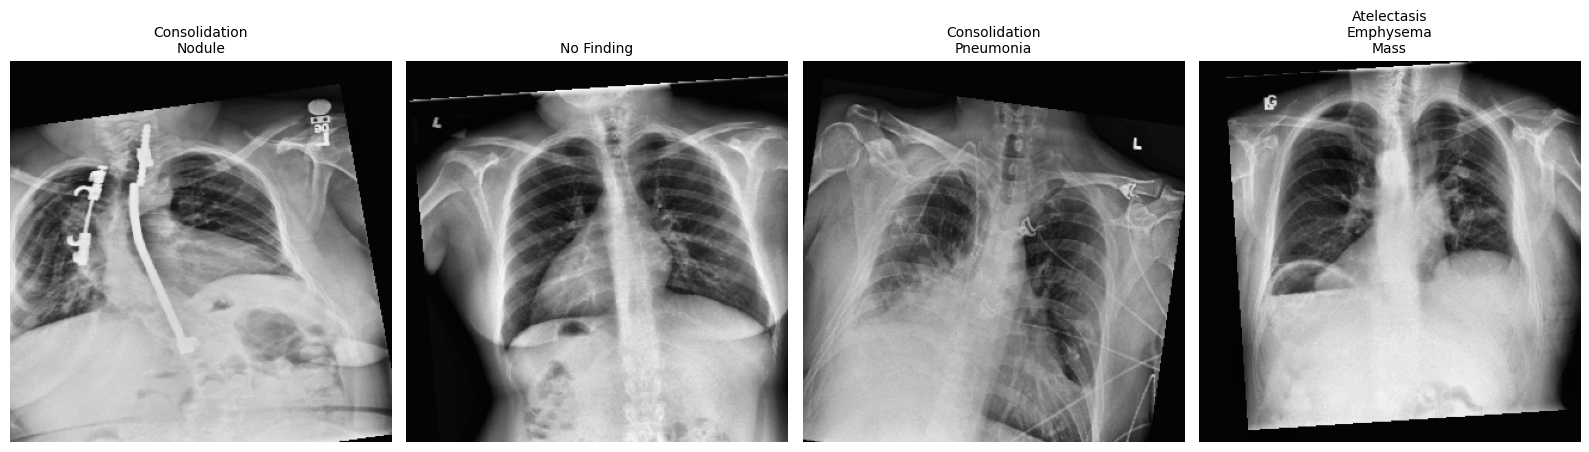

In [9]:
# Pull one batch
images, labels = next(train_gen)

# Check the values: If the mean is around 0.4-0.6, it's perfect. 
# If it's 0.001, it's too dark.
print(f"Image Min: {images[0].min():.4f}, Max: {images[0].max():.4f}, Mean: {images[0].mean():.4f}")

plt.figure(figsize=(16, 8))
for i in range(4):
    plt.subplot(1, 4, i+1)
    # No need to multiply by 255, imshow handles 0-1 float arrays perfectly
    plt.imshow(images[i])
    
    # Get labels for the title
    current_labels = [pathologies[idx] for idx, val in enumerate(labels[i]) if val == 1]
    plt.title("\n".join(current_labels) if current_labels else "No Finding", fontsize=10)
    plt.axis('off')
plt.tight_layout()
plt.show()

## 3. Model Architecture

**DenseNet121** is the "gold standard" for the NIH Chest X-ray dataset because its "dense blocks" (where every layer connects to every other layer) are excellent at capturing the subtle textures needed to identify things like Infiltration or Effusion.


### 3.1 Define the Model Architecture

**Multi-Label Classification**- a patient can have multiple diseases at once


In [10]:
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
import tensorflow.keras.metrics as metrics

# quick test model
# def build_chest_model(num_classes):
#     # 1. Load Pre-trained DenseNet121 (on ImageNet)
#     # include_top=False removes the final 1000-class ImageNet layer
#     base_model = DenseNet121(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
    
#     # 2. Add our custom "head" for the 14 pathologies
#     x = base_model.output
#     x = GlobalAveragePooling2D()(x) # Flattens the feature maps
#     x = Dropout(0.2)(x)             # Prevents overfitting
    
#     # Final layer: 14 units with 'sigmoid' for multi-label
#     predictions = Dense(num_classes, activation='sigmoid', dtype='float32')(x)
    
#     model = Model(inputs=base_model.input, outputs=predictions)
    
#     # 3. Compile the model
#     # We use a lower learning rate (1e-4) for transfer learning
#     model.compile(
#         optimizer=Adam(learning_rate=0.0001),
#         loss='binary_crossentropy',
#         metrics=[
#             metrics.BinaryAccuracy(name='accuracy'),
#             metrics.AUC(name='auc', multi_label=True) # AUC is the key metric here
#         ]
#     )
    
#     return model

def build_optimized_model():
    with strategy.scope():
        base_model = tf.keras.applications.DenseNet121(
            weights='imagenet', include_top=False, input_shape=(320, 320, 3)
        )
        # We start by unfreezing all layers for a full-data run
        base_model.trainable = True 
        
        x = tf.keras.layers.GlobalAveragePooling2D()(base_model.output)
        x = tf.keras.layers.Dropout(0.3)(x) # Slightly higher dropout for 320px
        
        predictions = tf.keras.layers.Dense(
            14, activation='sigmoid', dtype='float32'
        )(x)
        
        model = tf.keras.models.Model(inputs=base_model.input, outputs=predictions)
        
        model.compile(
            optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
            loss='binary_crossentropy',
            metrics=[tf.keras.metrics.AUC(name='auc', multi_label=True)]
        )
    return model

# Initialize the model
model = build_optimized_model()

# Print a summary to see the layers (this works on CPU)
# model.summary()

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


### 3.2 Set Up Training Callbacks

Training a deep model on 100,000 images takes time. You don't want to lose your progress if the session times out, and you don't want to overtrain.

In [11]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau


# Saving to /kaggle/working/ ensures you can download it later
checkpoint_path = "/kaggle/working/best_chest_model_v2.keras"   # v2 is used as a cancel of last training

# 1. Save the best version of the model automatically
checkpoint = ModelCheckpoint(
    checkpoint_path, 
    monitor='val_auc', 
    mode='max', 
    save_best_only=True, 
    verbose=1
)

# 2. Stop training if the validation AUC stops improving
early_stop = EarlyStopping(
    monitor='val_auc', 
    mode='max', 
    patience=5, 
    restore_best_weights=True
)

# 3. Lower the learning rate if the model hits a "plateau"
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss', 
    factor=0.1, 
    patience=3, 
    min_lr=1e-7, 
    verbose=1
)

callbacks_list = [checkpoint, early_stop, reduce_lr]

### 3.3 Handling Class Imbalance (The Strategy)

In multi-label classification, standard "class weights" (which tell the model a 1 is more important than a 0) are difficult to implement because each image has 14 different labels.

Don't use a custom loss function yet. Instead, rely on AUC (Area Under the Curve) as the primary metric. AUC is mathematically robust against class imbalance. If the model gets a high AUC on "Hernia" (the rarest class), it means it is successfully distinguishing it despite the small number of samples.

### 3.4 Enabale GPU and do the training (AUC)


1. Save your Notebook.
2. Go to the right sidebar -> Session options -> Accelerator.
3. Select GPU T4 x2. (The session will restart).Run All Cells (This will re-run the split, the generator, and the model definition).
4. Execute the Training Cell (Code below).

The NIH dataset is huge. If we use steps_per_epoch=len(train_gen), one epoch might take 40+ minutes.


* In the first run, we set steps_per_epoch=500 just to see if the loss is going down and the AUC is going up.
* Once it's working, remove that line to train on the full data.

In [12]:
# WARNING: This will take much longer than before (~45-60 mins per epoch)
# But it will be much more accurate.
# history = model.fit(
#     train_gen,
#     epochs=20,
#     validation_data=valid_gen,
#     steps_per_epoch=len(train_gen), # FULL DATA TRAINING
#     callbacks=callbacks_list,
#     verbose=1
# )

history = model.fit(
    train_gen,
    epochs=15,
    validation_data=valid_gen,
    initial_epoch=8,
    steps_per_epoch=len(train_gen), # FULL DATA TRAINING
    callbacks=callbacks_list,
    verbose=1
)

# Manual final save as backup
model.save('/kaggle/working/epoch15_final_model.keras')
print("Model saved successfully in /kaggle/working/")

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 9/15


I0000 00:00:1774958909.997293      71 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1774958909.997309      69 cuda_dnn.cc:529] Loaded cuDNN version 91002


1404/1404 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - auc: 0.6212 - loss: 0.2310
Epoch 9: val_auc improved from -inf to 0.76823, saving model to /kaggle/working/best_chest_model_v2.keras
1404/1404 ━━━━━━━━━━━━━━━━━━━━ 5450s 4s/step - auc: 0.6213 - loss: 0.2309 - val_auc: 0.7682 - val_loss: 0.1547 - learning_rate: 1.0000e-04
Epoch 10/15
1404/1404 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - auc: 0.7753 - loss: 0.1550
Epoch 10: val_auc improved from 0.76823 to 0.79325, saving model to /kaggle/working/best_chest_model_v2.keras
1404/1404 ━━━━━━━━━━━━━━━━━━━━ 5108s 4s/step - auc: 0.7753 - loss: 0.1550 - val_auc: 0.7932 - val_loss: 0.1497 - learning_rate: 1.0000e-04
Epoch 11/15
1404/1404 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - auc: 0.8056 - loss: 0.1494
Epoch 11: val_auc did not improve from 0.79325
1404/1404 ━━━━━━━━━━━━━━━━━━━━ 5086s 4s/step - auc: 0.8056 - loss: 0.1494 - val_auc: 0.7892 - val_loss: 0.1500 - learning_rate: 1.0000e-04
Epoch 12/15
1404/1404 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - auc: 0.8158 - loss: 0.1465


#### 3.4.3 Evaluating with ROC Curves

178/178 ━━━━━━━━━━━━━━━━━━━━ 363s 2s/step


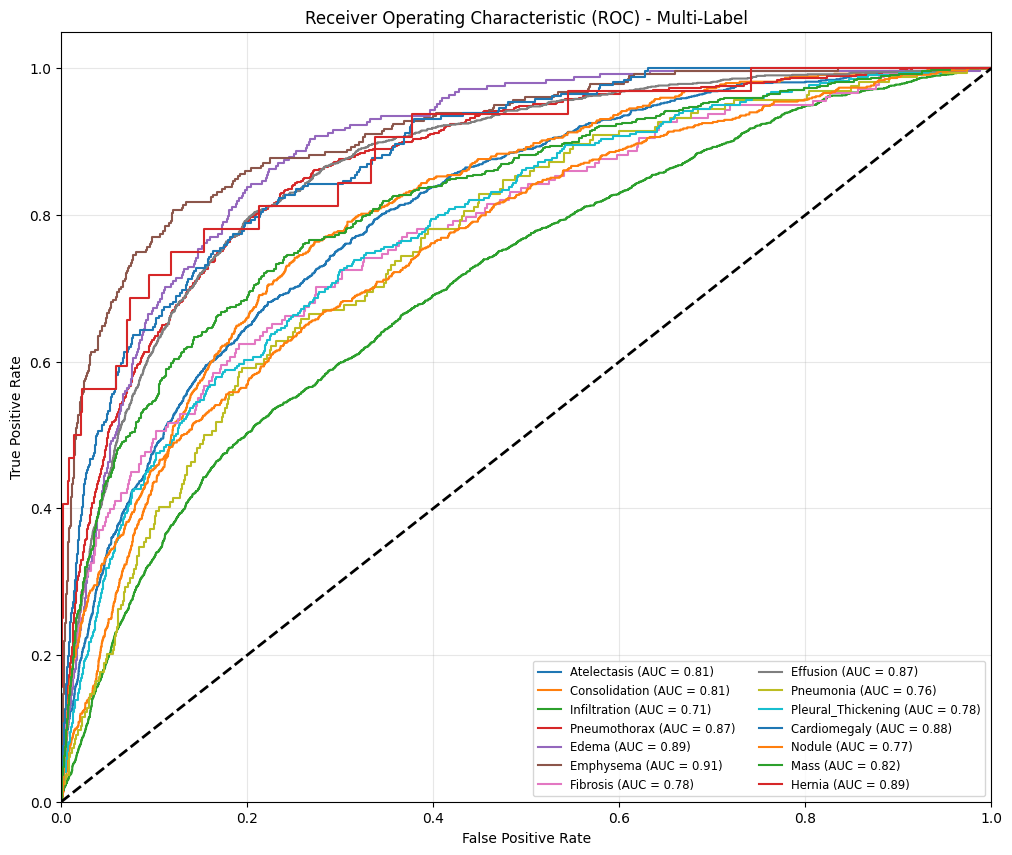


Mean AUC across all classes: 0.8254


In [13]:
from sklearn.metrics import roc_curve, auc

# 1. Get predictions for the test set
# This might take a few minutes even on GPU
test_gen.reset()
predictions = model.predict(test_gen, steps=len(test_gen), verbose=1)
y_true = test_df[pathologies].values

# 2. Plot ROC Curves
plt.figure(figsize=(12, 10))
for i, pathology in enumerate(pathologies):
    # Calculate ROC for each pathology
    fpr, tpr, _ = roc_curve(y_true[:, i], predictions[:, i])
    roc_auc = auc(fpr, tpr)
    
    plt.plot(fpr, tpr, label=f'{pathology} (AUC = {roc_auc:.2f})')

# Plot the "Random Guess" diagonal line
plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) - Multi-Label')
plt.legend(loc="lower right", fontsize='small', ncol=2)
plt.grid(alpha=0.3)
plt.show()

# 3. Print Mean AUC
all_aucs = [auc(roc_curve(y_true[:, i], predictions[:, i])[0], 
                roc_curve(y_true[:, i], predictions[:, i])[1]) for i in range(len(pathologies))]
print(f"\nMean AUC across all classes: {np.mean(all_aucs):.4f}")